## Validación de la curva de demanda

A lo largo del proyecto se ha estimado la relación entre el precio y la demanda de Pepsi por dos caminos independientes:

- **Paramétrico (fase 3):** una regresión log-log que impone una forma funcional concreta y resume la respuesta en un único parámetro, la elasticidad. La curva de demanda que implica es

  $$Q = A \cdot P^{\varepsilon}, \qquad \varepsilon = -4{,}62$$

  o, en logaritmos, la relación lineal que se estimó directamente:

  $$\ln Q = \ln A + \varepsilon \cdot \ln P$$

  Su virtud es la interpretabilidad; su límite, que asume **elasticidad constante**: la pendiente es la misma a cualquier nivel de precio.

- **No paramétrico (fase 4):** un modelo LightGBM que aprende la relación precio-demanda sin imponerle forma alguna. Puede capturar curvaturas, escalones o cambios de pendiente que la regresión, por construcción, no ve.

Validar la curva de demanda consiste en **contrastar ambas estimaciones**. Si dos métodos tan distintos —una regresión econométrica rígida y un modelo de ML flexible— describen una relación precio-demanda parecida, se refuerza la confianza en esa relación de cara a la optimización de precio (fase siguiente). Si divergen, la discrepancia informa sobre los límites de cada enfoque y sobre con cuál conviene quedarse.

La elasticidad puede recuperarse de cualquier curva como la pendiente en escala logarítmica:

$$\varepsilon(P) = \frac{d \ln Q}{d \ln P}$$

En la regresión esta pendiente es constante (−4,62). En LightGBM puede variar con el precio, y comparar ambas es el núcleo de esta validación.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go


from skforecast.utils import load_forecaster

Vamos a reconstruir la serie agregada creada en el notebook 4.

In [ ]:
# Modelo entrenado en el 04 (train-only, hiperparámetros óptimos)
forecaster = load_forecaster('../models/forecaster_pepsi.joblib', verbose=True)

FIN_TRAIN = '1996-05-01'

modelo_agregado = pd.read_parquet('../data/processed/pepsi_2l_model_ready.parquet').asfreq('7D') # Serie agregada notebook 4

# Separamos conjuntos
train = modelo_agregado.loc[:FIN_TRAIN]
test = modelo_agregado.loc[modelo_agregado.index > FIN_TRAIN]

y_train = train['UNIDADES']
exog_train = train.drop(columns=['UNIDADES'])

X_train, _ = forecaster.create_train_X_y(y=y_train, exog=exog_train)
print(X_train.columns.tolist())


ForecasterRecursive 
Estimator: LGBMRegressor 
Lags: [1 2 3 4] 
Window features: None 
Calendar features: None 
Window size: 4 
Series name: UNIDADES 
Exogenous included: True 
Exogenous names: 
    PRECIO_REF, DESCUENTO, PRECIO_REF_COCA, FESTIVO, WEEK_YEAR, MES 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('1991-01-03 00:00:00'), Timestamp('1996-04-25 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <7 * Days> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.04299035704989309,
    'max_depth': 2, 'min_child_samples': 10, 'min_child_weight': 0.001,
    'min_split_gain': 0.0, 'n_estimators': 250, 'n_jobs': -1, 'num_leaves': 27,
    'objective': None, 'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda':
    0.

In [45]:
# Fila base: semana representativa (mediana de cada variable), sin festivo
# Valores base estáticos
base = X_train.median().to_dict()
base['FESTIVO'] = 0 # fijamos festivo con valor 0, es decir, no hay festivos.

# Movemos el precio vía descuento (canal con soporte); precio regular fijo
PRECIO_REG  = float(exog_train['PRECIO_REF'].median()) # fijamos precio fijo con mediana
dto_max     = float(np.quantile(exog_train['DESCUENTO'], 0.99))   # Fijamos un dto máximo con el cuantil 99
rejilla_dto = np.linspace(0.0, dto_max, 100) # creamos un espacio lineal con 10 valores comprendidos entre 0 y el dto máximo

curva = pd.DataFrame([base] * len(rejilla_dto)) # creamos 100 registros comprendidos en el espacio lineal
curva['PRECIO_REF'] = PRECIO_REG # ajustamos precio referncia a la mediana
curva['DESCUENTO'] = rejilla_dto
curva['PRECIO_EFECTIVO'] = PRECIO_REG * np.exp(-curva['DESCUENTO'])

# Predicción sobre el regresor pelado (mismas columnas y orden que X_train)
curva['Q'] = forecaster.estimator.predict(curva[X_train.columns]) # predicimos demanda
curva.head()

,lag_1,lag_2,lag_3,lag_4,PRECIO_REF,DESCUENTO,PRECIO_REF_COCA,FESTIVO,WEEK_YEAR,MES,PRECIO_EFECTIVO,Q
0,130.126899,130.126899,131.0099,132.828107,1.586357,0.000000,1.584686,0,25.0,6.0,1.586357,107.532985
1,130.126899,130.126899,131.0099,132.828107,1.586357,0.005246,1.584686,0,25.0,6.0,1.578057,108.336769
2,130.126899,130.126899,131.0099,132.828107,1.586357,0.010491,1.584686,0,25.0,6.0,1.569801,111.098325
3,130.126899,130.126899,131.0099,132.828107,1.586357,0.015737,1.584686,0,25.0,6.0,1.561588,111.321921
4,130.126899,130.126899,131.0099,132.828107,1.586357,0.020983,1.584686,0,25.0,6.0,1.553418,112.164993


Lo que se acaba de hacer es congelar un valor de cada variable de la serie, porque "lo único que nos interesa es mover el precio efectivo, y como el precio regular apenas varía, lo hacemos a través del descuento"

Para el descuento se selecciona el percentil 99, así dejamos fuera un descuento que tal vez solo se aplicó una semana. Con este descuento máximo seleccionado, se crea un espacio lineal de 100 valores que representan los diferentes descuentos que se van a probar.

Procedemos a crear 100 semanas ficticias que son idénticas salvo en el descuento, que contiene diferentes valores entre 0 y el descuento máximo seleccionado.

Para calcular el precio real que pagaría el cliente hay que deshacer el logaritmo que se encuentra presente en el descuento aplicando una exponencial.

Finalmente se pasan las 100 semanas al modelo de ML y se predice la demanda de cada una. De esta forma obtenemos la curva de demanda

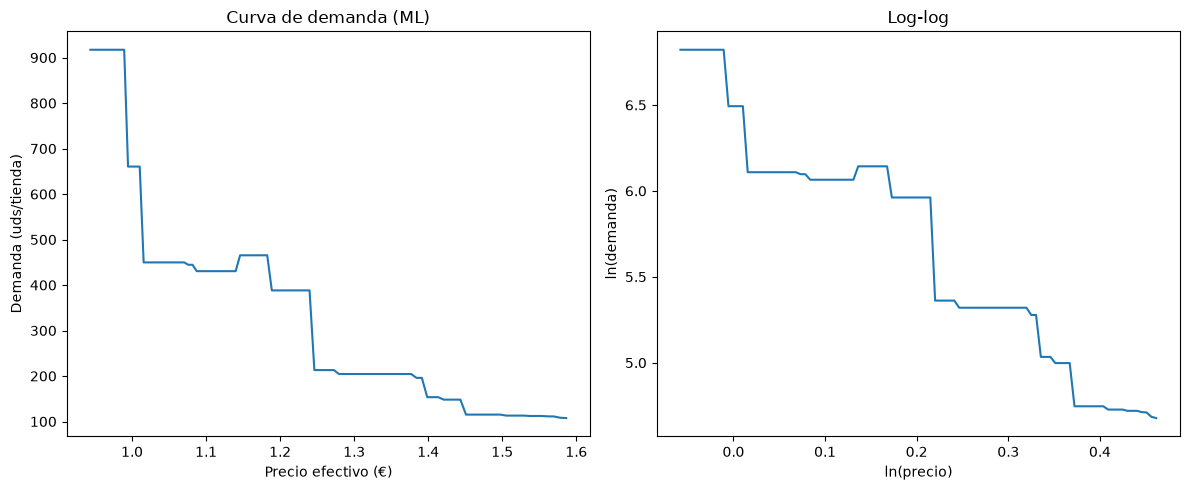

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(curva['PRECIO_EFECTIVO'], curva['Q'])
ax[0].set(xlabel='Precio efectivo (€)', ylabel='Demanda (uds/tienda)', title='Curva de demanda (ML)')
ax[1].plot(np.log(curva['PRECIO_EFECTIVO']), np.log(curva['Q']))
ax[1].set(xlabel='ln(precio)', ylabel='ln(demanda)', title='Log-log')
plt.tight_layout(); plt.show()

Para validar visualmente la curva de demanda se representan juntas, en los mismos ejes, las dos estimaciones: la curva no paramétrica de LightGBM y la recta log-log de la regresión (pendiente −4,62). La comparación se hace en **escala logarítmica**, porque es ahí donde la elasticidad es directamente la pendiente y donde la relación log-log es una recta: si ambas describen la misma respuesta de la demanda al precio, deberían mostrar una pendiente similar.

Hay una dificultad que resolver antes de comparar. La recta log-log de la fase 3 tiene una altura (un intercepto) que proviene de un modelo con efectos fijos de tienda y un nivel de demanda distinto al de la serie agregada sobre la que se construyó la curva de LightGBM. Por tanto, comparar las alturas absolutas no tiene sentido: lo que se valida es la **pendiente** (la elasticidad), no el nivel. Para hacerlas comparables se ancla la recta log-log al mismo punto de partida que la curva de LightGBM, de modo que ambas arranquen juntas y solo se compare cómo caen. Es la comparación honesta: misma pregunta (¿con qué fuerza cae la demanda al subir el precio?), dos métodos. 

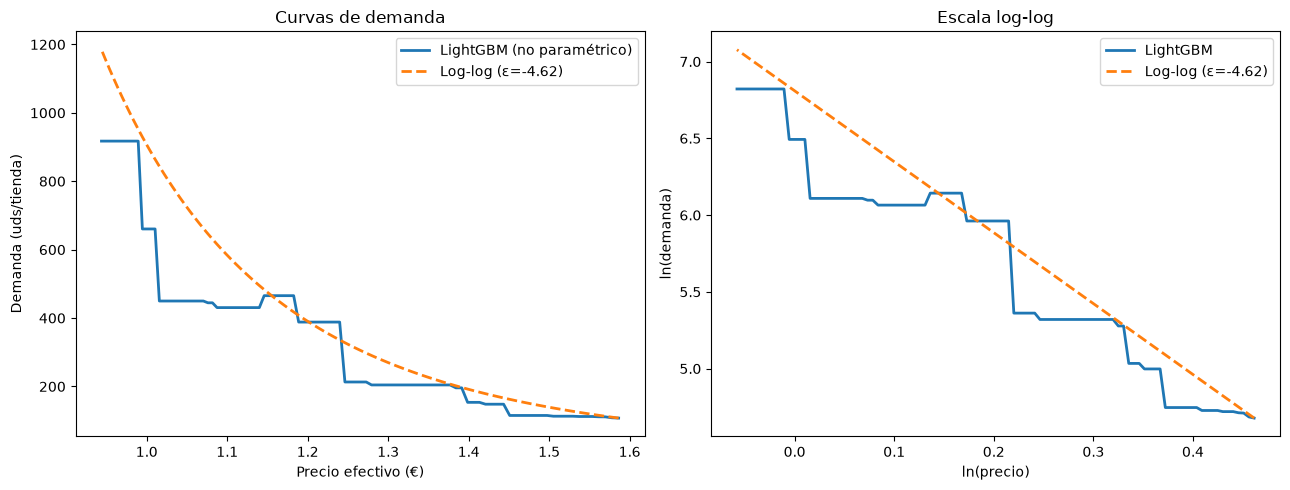

In [ ]:
# Datos en log de la curva de LightGBM; Pasamos precio efectivo y demanda a logaritmo
ln_p = np.log(curva["PRECIO_EFECTIVO"].values) #precio
ln_q_ml = np.log(curva["Q"].values) # demanda

# Recta log-log de la regresión, anclada al inicio de la curva ML
EPSILON = -4.62

# la recta pasa por el primer punto de la curva ML (precio más bajo)
ln_p0, ln_q0 = ln_p[0], ln_q_ml[0] # precio y demanda más bajos

# ecuación recta log-log; partiendo de la demanda inicial, por cada ud que el precio se aleja del precio inicial, la demanda cambia epsilon
ln_q_reg = ln_q0 + EPSILON * (ln_p - ln_p0)   

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# escala natural
ax[0].plot(curva["PRECIO_EFECTIVO"], curva["Q"], label="LightGBM (no paramétrico)", lw=2)
ax[0].plot(curva["PRECIO_EFECTIVO"], np.exp(ln_q_reg), label="Log-log (ε=-4.62)", ls="--", lw=2)
ax[0].set(xlabel="Precio efectivo (€)", ylabel="Demanda (uds/tienda)",
          title="Curvas de demanda")
ax[0].legend()

# escala log-log (donde la elasticidad es la pendiente)
ax[1].plot(ln_p, ln_q_ml, label="LightGBM", lw=2)
ax[1].plot(ln_p, ln_q_reg, label="Log-log (ε=-4.62)", ls="--", lw=2)
ax[1].set(xlabel="ln(precio)", ylabel="ln(demanda)", title="Escala log-log")
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Pendiente media de la curva de LightGBM en escala log-log = elasticidad implícita
elasticidad_ml, intercepto = np.polyfit(ln_p, ln_q_ml, 1)

print(f"Elasticidad implícita (LightGBM): {elasticidad_ml:.2f}")
print(f"Elasticidad regresión: {EPSILON:.2f}")

Elasticidad implícita (LightGBM): -4.24
Elasticidad regresión (fase 3):   -4.62


La elasticidad implícita de la curva de LightGBM es **−4,24**, frente a los **−4,62** estimados por la regresión log-log de la fase 3. Dos métodos completamente independientes —una regresión econométrica que impone elasticidad constante y un modelo de ML sin forma funcional impuesta— llegan a una elasticidad prácticamente equivalente, con una diferencia de apenas 0,38 puntos.

Esta concordancia valida la relación precio-demanda estimada en el proyecto: no es un artefacto del método elegido, sino una regularidad robusta presente en los datos. Cuando dos enfoques tan distintos coinciden, la confianza en el resultado es mucho mayor que la que daría cualquiera de los dos por separado.

La pequeña diferencia restante es coherente y esperable. La curva de LightGBM resulta algo menos elástica porque se construye sobre la serie agregada, moviendo el precio a través del descuento y con el precio del rival fijo; la regresión, en cambio, estimaba la elasticidad sobre el panel completo con efectos fijos de tienda, una situación más "pura" que arroja el valor más extremo. Ambas miden la misma relación, en variantes ligeramente distintas.

Conviene matizar el alcance del número. La elasticidad implícita (−4,24) es un resumen: se obtiene ajustando una recta a una curva que, por la naturaleza de LightGBM, es escalonada y no tiene una única pendiente. Representa bien la respuesta *media* de la demanda al precio, pero aplasta las no linealidades que el modelo flexible sí captura. La coincidencia con la regresión es, por tanto, de tendencia y magnitud, no una igualdad exacta punto por punto. 

En conjunto, el proyecto dispone de una **curva de demanda validada por dos vías independientes**, lo que da fundamento sólido para el paso siguiente: la optimización de precio. Se puede confiar en que, al buscar el precio que maximiza el ingreso, la relación precio-demanda sobre la que se optimiza es fiable dentro del rango de precios analizado.